In [ ]:
import sys
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
import numpy as np
import random
from torch.utils.data import TensorDataset
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset

sample_size = 5000 # real data number
filter_threshold = 0.5 # p=0.5

# One-hot encoding helper
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

############################ real data training ############################
seed = 0
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 200
lr = 1e-3
patience = 5

# Load MNIST
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset = Subset(full_dataset, range(sample_size))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
trigger_times = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_{sample_size}.pth")
print(f"Model saved to model_saved/cvae_mnist_{sample_size}.pth")

model0_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_{sample_size}.pth"
############################ generate synthetic data ############################

model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))
model.eval()

# large sample size for training
latent_dim = model.latent_dim
device = next(model.parameters()).device
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=6000000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)

# large sample size for training
latent_dim = model.latent_dim
device = next(model.parameters()).device
gen_imgs_for_synthetic_training,y_for_synthetic_training = generate_images_in_batches(
    model=model,
    total_samples=50000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
########################## train model using unfiltered synthetic data ##########################
images = gen_imgs_for_synthetic_training  # shape: [N, 1, 28, 28]
labels = y_for_synthetic_training # shape: [N]

print(f"Loaded {images.shape[0]} unfiltered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]

# Create dataset and dataloader
dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_unfiltered_synthetic_data_{sample_size}.pth")
model00_path = f"model_saved/cvae_mnist_unfiltered_synthetic_data_{sample_size}.pth"

############################ filter synthetic data ############################

from discriminator import Discriminator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

#data = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}.pt")
#synthetic_images = data['images']  

synthetic_loader = DataLoader(gen_imgs_before_filter, batch_size=512)

all_probs = []

with torch.no_grad():
    for batch in synthetic_loader:
        batch = batch.to(device)
        probs = D(batch)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)
# Flatten probs to shape [N]
probs = all_probs.squeeze(1)

# Load images and labels
images = gen_imgs_before_filter#data['images']      # [N, 1, 28, 28]
labels = y_before_filter #data['labels']      # [N]
# Create mask for p > filter_threshold
mask = probs > filter_threshold

# Apply mask
filtered_images = images[mask]
filtered_labels = labels[mask]

print(f"Selected {filtered_images.shape[0]} samples with p > {filter_threshold}")
# Save to file
torch.save({
    'images': filtered_images,
    'labels': filtered_labels
}, f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")


############################ synthetic data retraining ############################

images = filtered_images  # shape: [N, 1, 28, 28]
labels = filtered_labels  # shape: [N]

print(f"Loaded {images.shape[0]} filtered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]

# Create dataset and dataloader
dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth")
model1_path = f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth"

Epoch [1/200], Train Loss: 463.9365
Epoch [2/200], Train Loss: 293.3153
Epoch [3/200], Train Loss: 237.4877
Epoch [4/200], Train Loss: 220.8071
Epoch [5/200], Train Loss: 213.3626
Epoch [6/200], Train Loss: 209.0519
Epoch [7/200], Train Loss: 205.3083
Epoch [8/200], Train Loss: 201.5152
Epoch [9/200], Train Loss: 196.6978
Epoch [10/200], Train Loss: 191.1078
Epoch [11/200], Train Loss: 185.5030
Epoch [12/200], Train Loss: 180.5003
Epoch [13/200], Train Loss: 175.1994
Epoch [14/200], Train Loss: 169.7864
Epoch [15/200], Train Loss: 165.9490
Epoch [16/200], Train Loss: 162.1987
Epoch [17/200], Train Loss: 159.3711
Epoch [18/200], Train Loss: 156.6087
Epoch [19/200], Train Loss: 153.8889
Epoch [20/200], Train Loss: 152.2136
Epoch [21/200], Train Loss: 149.9037
Epoch [22/200], Train Loss: 148.4437
Epoch [23/200], Train Loss: 146.4496
Epoch [24/200], Train Loss: 145.0888
Epoch [25/200], Train Loss: 143.7641
Epoch [26/200], Train Loss: 142.5672
Epoch [27/200], Train Loss: 140.5902
Epoch [28/

/tmp/ipykernel_1955635/3457173712.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))


Loaded 50000 unfiltered synthetic samples
Epoch [1/200], Train Loss: 174.8425
Epoch [2/200], Train Loss: 139.6115
Epoch [3/200], Train Loss: 134.5951
Epoch [4/200], Train Loss: 132.9780
Epoch [5/200], Train Loss: 132.1885
Epoch [6/200], Train Loss: 131.6848
Epoch [7/200], Train Loss: 131.3527
Epoch [8/200], Train Loss: 131.1333
Epoch [9/200], Train Loss: 131.0141
Epoch [10/200], Train Loss: 130.8450
Epoch [11/200], Train Loss: 130.7124
Epoch [12/200], Train Loss: 130.6472
Epoch [13/200], Train Loss: 130.6073
Epoch [14/200], Train Loss: 130.5390
Epoch [15/200], Train Loss: 130.5076
Epoch [16/200], Train Loss: 130.4694
Epoch [17/200], Train Loss: 130.4179
Epoch [18/200], Train Loss: 130.3775
Epoch [19/200], Train Loss: 130.3569
Epoch [20/200], Train Loss: 130.3371
Epoch [21/200], Train Loss: 130.2872
Epoch [22/200], Train Loss: 130.2824
Epoch [23/200], Train Loss: 130.2249
Epoch [24/200], Train Loss: 130.2147
Epoch [25/200], Train Loss: 130.1983
Epoch [26/200], Train Loss: 130.2003
Early

/tmp/ipykernel_1955635/3457173712.py:198: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))


Selected 3577 samples with p > 0.5
Loaded 3577 filtered synthetic samples
Epoch [1/200], Train Loss: 295.8095
Epoch [2/200], Train Loss: 184.9373
Epoch [3/200], Train Loss: 163.9649
Epoch [4/200], Train Loss: 148.2771
Epoch [5/200], Train Loss: 137.2011
Epoch [6/200], Train Loss: 130.2460
Epoch [7/200], Train Loss: 125.2264
Epoch [8/200], Train Loss: 122.0628
Epoch [9/200], Train Loss: 119.1385
Epoch [10/200], Train Loss: 116.8074
Epoch [11/200], Train Loss: 114.7682
Epoch [12/200], Train Loss: 112.8547
Epoch [13/200], Train Loss: 111.0850
Epoch [14/200], Train Loss: 109.5289
Epoch [15/200], Train Loss: 108.3923
Epoch [16/200], Train Loss: 107.0899
Epoch [17/200], Train Loss: 106.1579
Epoch [18/200], Train Loss: 104.9854
Epoch [19/200], Train Loss: 104.2475
Epoch [20/200], Train Loss: 103.3760
Epoch [21/200], Train Loss: 102.6204
Epoch [22/200], Train Loss: 102.1810
Epoch [23/200], Train Loss: 101.4885
Epoch [24/200], Train Loss: 101.1214
Epoch [25/200], Train Loss: 100.4439
Epoch [26/

# Evaluate

## visualize

In [9]:
import sys
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
import numpy as np
import random
from torch.utils.data import TensorDataset
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset

sample_size = 1000 # real data number
filter_threshold = 0.5 # p=0.5
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [10]:
model1_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth"
model0_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_{sample_size}.pth"
model00_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_unfiltered_synthetic_data_{sample_size}.pth"

In [12]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 200
lr = 1e-3
patience = 5

/tmp/ipykernel_1955635/3546602697.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load(model1_path, map_location=device))
/tmp/ipykernel_195

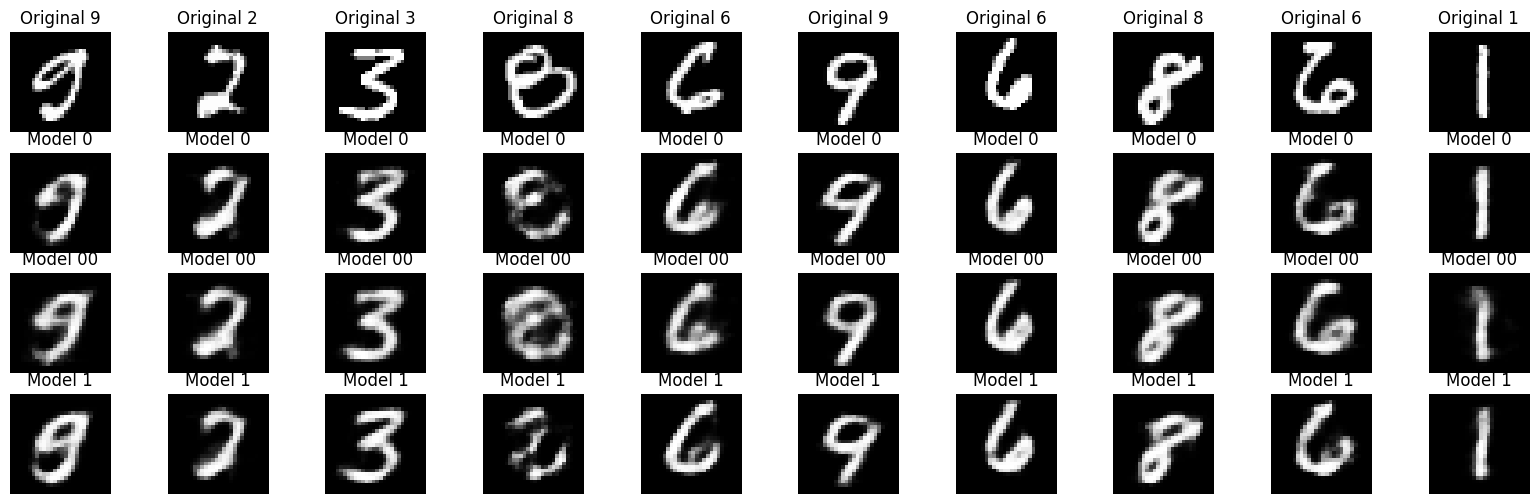

In [13]:
# reconstruct some test data and show the result
model1 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)

model1.load_state_dict(torch.load(model1_path, map_location=device))
model1.eval()

model0 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model0.load_state_dict(torch.load(model0_path, map_location=device))
model0.eval()

model00 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model00.load_state_dict(torch.load(model00_path, map_location=device))
model00.eval()

# Get some test data
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True) # batch size 10 to get 10 samples
data_iter = iter(test_loader)
test_images, test_labels = next(data_iter)
test_images = test_images.view(-1, 784).to(device)  # flatten   to [10, 784]
test_labels_onehot = F.one_hot(test_labels, num_classes=10).float().to(device)  # to one-hot    to [10, 10]     
with torch.no_grad():
    recon_images0, _, _ = model0(test_images, test_labels_onehot)
    recon_images1, _, _ = model1(test_images, test_labels_onehot)
    recon_images00, _, _ = model00(test_images, test_labels_onehot)
recon_images0 = recon_images0.view(-1, 1, 28, 28).cpu()
recon_images1 = recon_images1.view(-1, 1, 28, 28).cpu()
recon_images00 = recon_images00.view(-1, 1, 28, 28).cpu()
test_images = test_images.view(-1, 1, 28, 28).cpu() # reshape back to [10, 1, 28, 28]

# Plot original and reconstructed images side by side
fig, axes = plt.subplots(4, 10, figsize=(20, 6))
for i in range(10):
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Original {test_labels[i].item()}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(recon_images0[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Model 0')
    axes[1, i].axis('off')

    axes[2, i].imshow(recon_images00[i].squeeze(), cmap='gray')
    axes[2, i].set_title('Model 00')
    axes[2, i].axis('off')

    axes[3, i].imshow(recon_images1[i].squeeze(), cmap='gray')
    axes[3, i].set_title('Model 1')
    axes[3, i].axis('off')

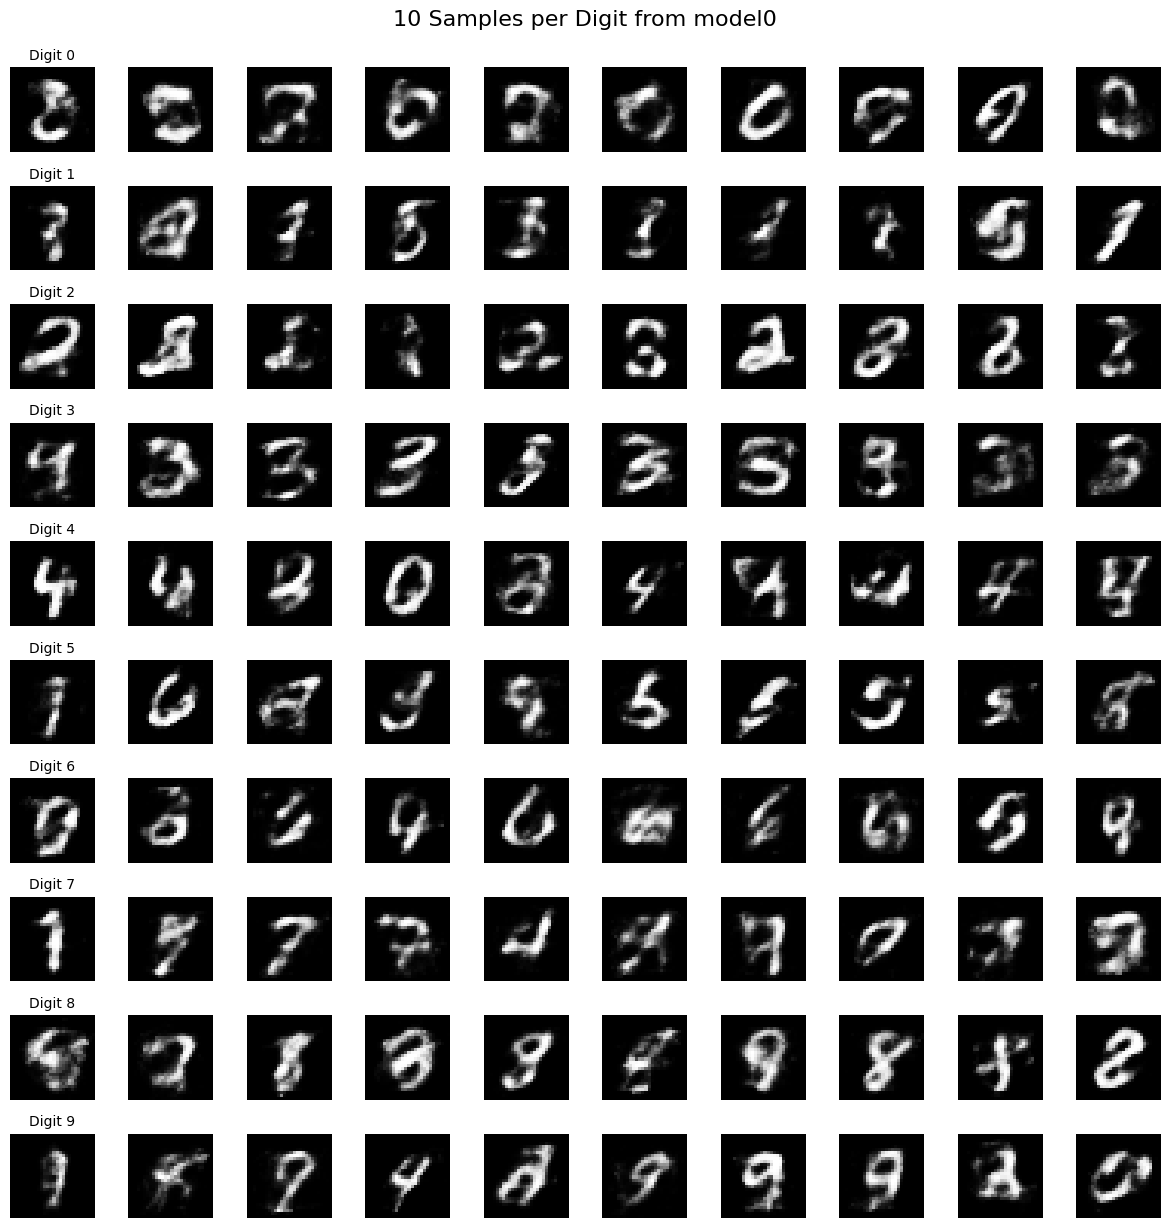

In [14]:
model=model0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model0,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model0", y=1.02, fontsize=16)
plt.show()


/tmp/ipykernel_1955635/2957307528.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_s

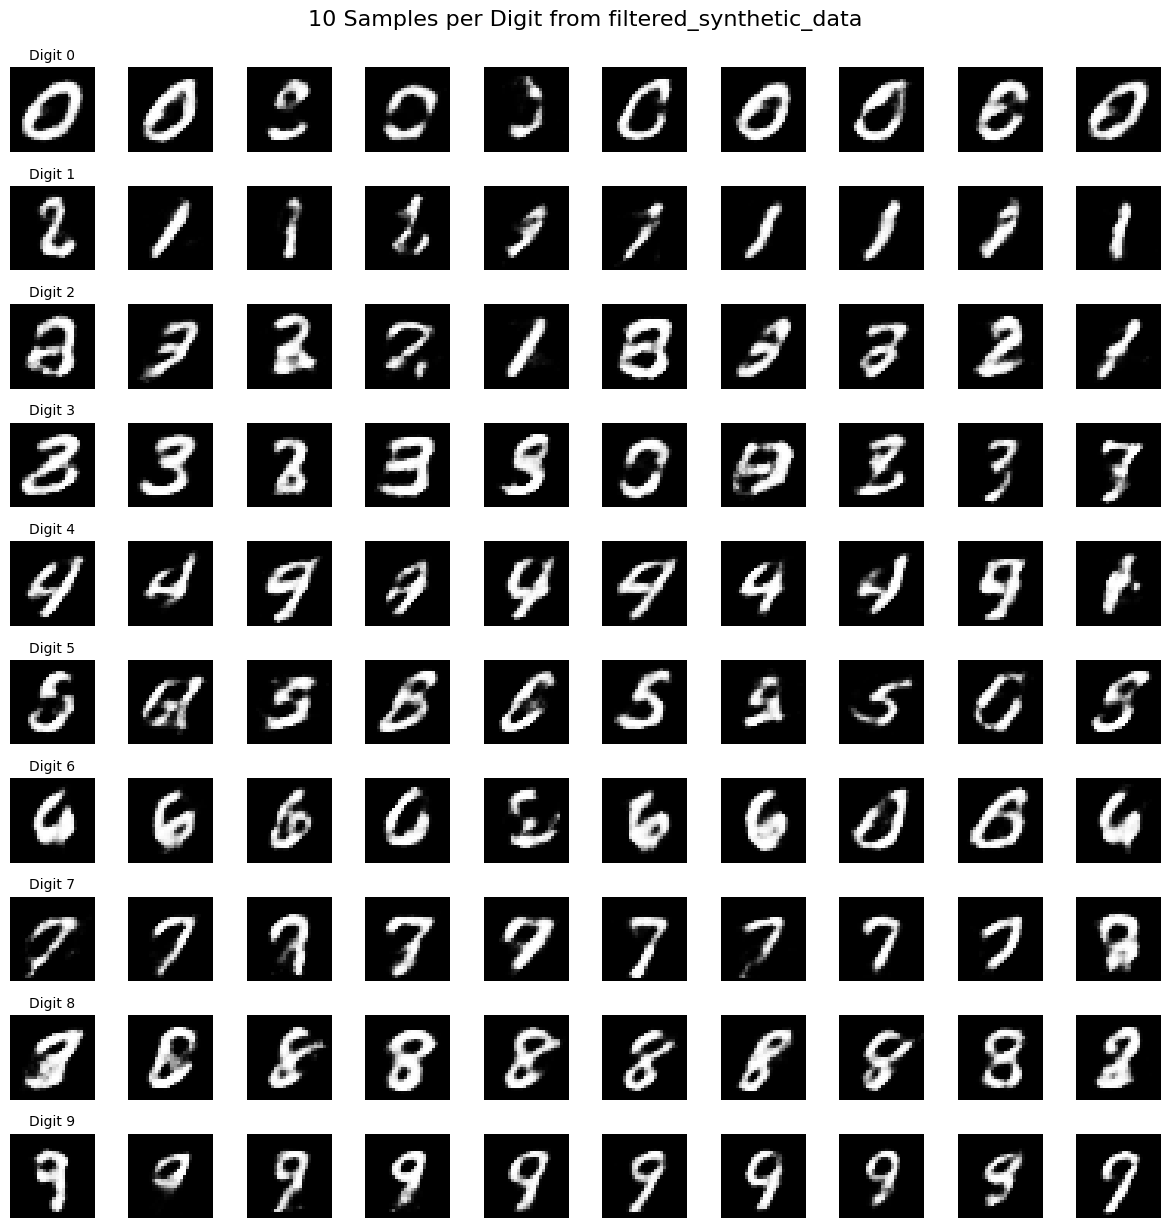

In [15]:
import os
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
data = torch.load(f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")

images = data['images']    # Tensor [N, 1, 28, 28]
labels = data['labels']  

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from filtered_synthetic_data", y=1.02, fontsize=16)
plt.show()



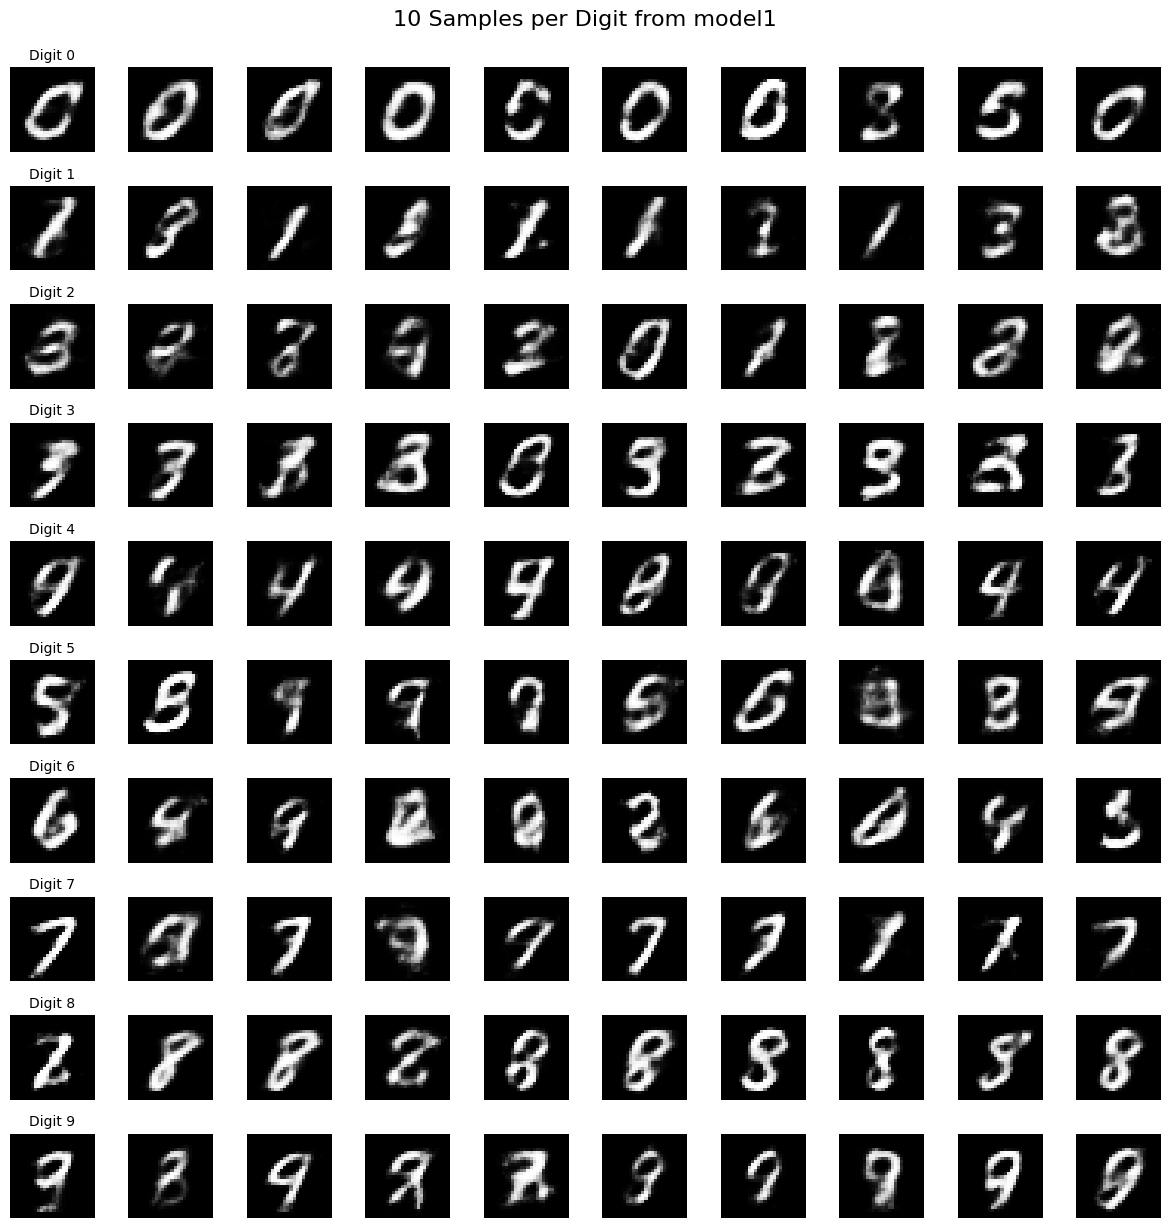

In [16]:
model=model1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# large sample size for training


synthetic_gen_size = 6000
# large sample size for training

gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model1,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model1", y=1.02, fontsize=16)
plt.show()

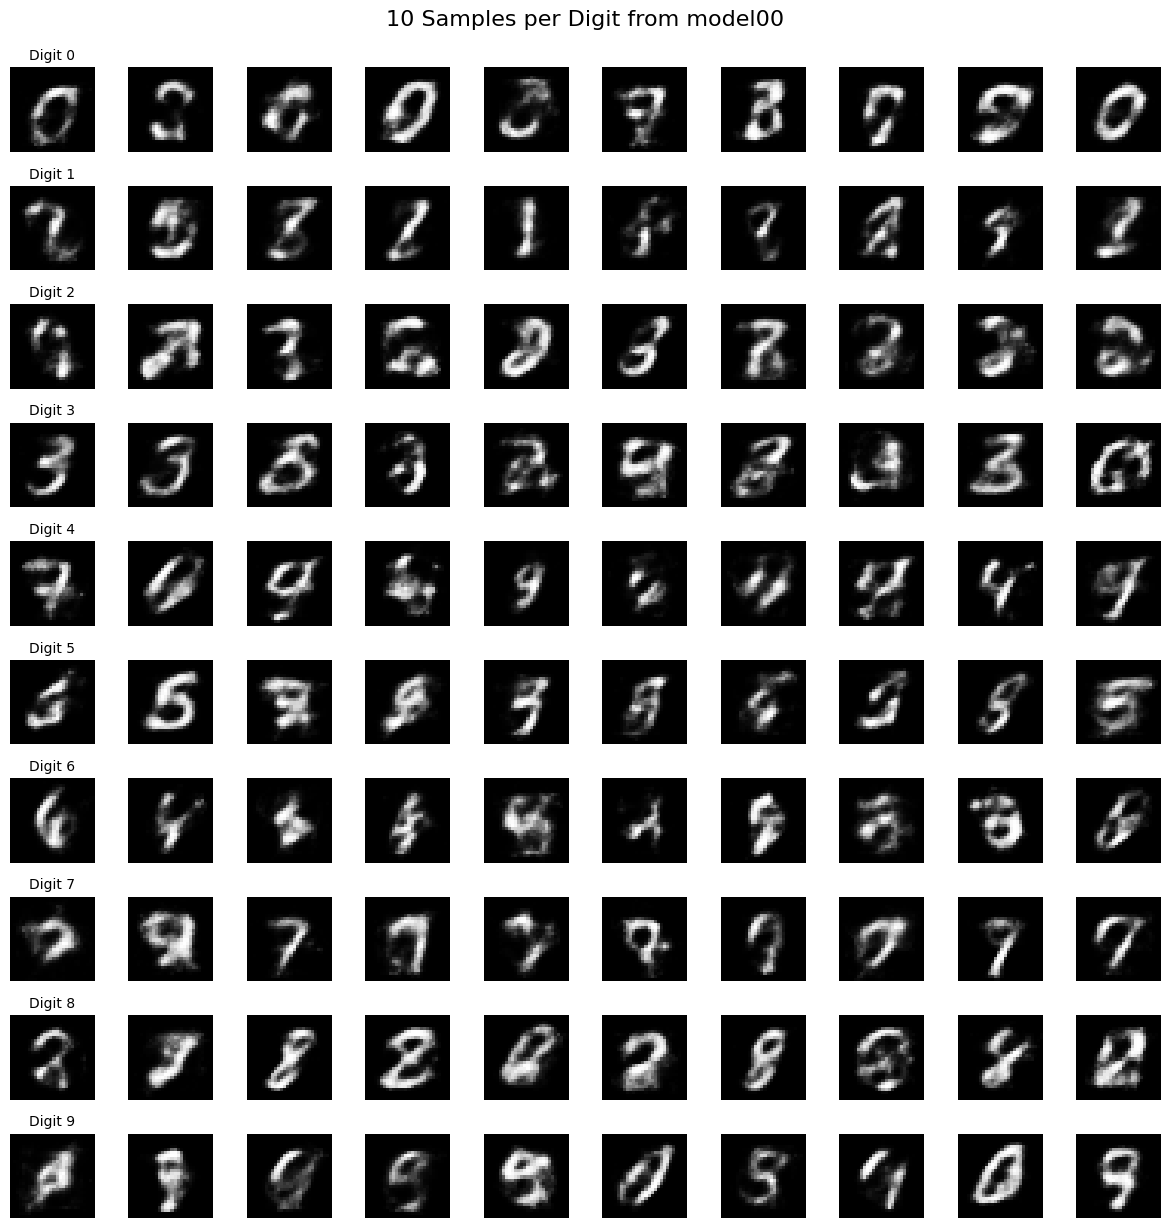

In [17]:
model=model00 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# large sample size for training


synthetic_gen_size = 6000
# large sample size for training

gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model00,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model00", y=1.02, fontsize=16)
plt.show()

## Calculate loss

In [8]:
def evaluate_cvae(model, dataloader, device, num_classes=10):
    """
    Evaluate a CVAE model on a given dataloader.

    Args:
        model: The trained CVAE model.
        dataloader: PyTorch DataLoader for evaluation.
        device: torch.device('cuda') or torch.device('cpu').
        num_classes: Number of label classes (default=10).

    Returns:
        dict with average total loss, reconstruction loss (BCE), and KL divergence.
    """
    model.eval()
    total_loss = 0.0
    total_recon_loss = 0.0
    total_kl = 0.0
    num_samples = 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.view(-1, 784).to(device)
            y = F.one_hot(y, num_classes=num_classes).float().to(device)

            recon_x, mu, logvar = model(x, y)
            BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
            KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = BCE + KLD

            total_loss += loss.item()
            total_recon_loss += BCE.item()
            total_kl += KLD.item()
            num_samples += x.size(0)

    return {
        "avg_total_loss": total_loss / num_samples,
        "avg_recon_loss": total_recon_loss / num_samples,
        "avg_kl_divergence": total_kl / num_samples
    }

test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model0_score = evaluate_cvae(model0, test_loader, device)
model1_score = evaluate_cvae(model1, test_loader, device)
model00_score = evaluate_cvae(model00, test_loader, device)

# save the scores tp compare_result
compare_result = {
    "model0": model0_score,
    "model1": model1_score,
    "model00": model00_score
}
# Print the scores
print(f"Model 1 (original) scores: {model0_score}")
print(f"Model 2 (filtered synthetic) scores: {model1_score}")
print(f"Model 00 (unfiltered synthetic) scores: {model00_score}")


NameError: name 'model0' is not defined

In [19]:
model=model0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value0 = calculate_fid_score_2(real_ds, synthetic_ds)

In [20]:
model=model1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value1= calculate_fid_score_2(real_ds, synthetic_ds)

In [21]:
model=model00
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value00= calculate_fid_score_2(real_ds, synthetic_ds)

In [22]:
fid_value0, fid_value1, fid_value00

(180.1414337158203, 161.802001953125, 193.72445678710938)

In [23]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision.transforms.functional import resize
from torchvision.models.inception import inception_v3
from sklearn.neighbors import NearestNeighbors

@torch.no_grad()
def extract_inception_features(dataset, batch_size=256, device=None):
    """
    Extract 2048-D features from the Inception-v3 pool3 layer.
    Returns a numpy array of shape (N, 2048) with float32 dtype.
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = inception_v3(pretrained=True, transform_input=False).to(device)
    model.fc = torch.nn.Identity()  # remove classification head
    model.eval()

    feats = []
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        if imgs.dim() == 3:
            imgs = imgs.unsqueeze(0)
        if imgs.shape[1] == 1:  # grayscale -> RGB
            imgs = imgs.repeat(1, 3, 1, 1)
        imgs = resize(imgs, [299, 299], antialias=True).to(device, dtype=torch.float32)
        if imgs.max() <= 1:
            imgs = imgs * 255.0
        feats.append(model(imgs).cpu())
    feats = torch.cat(feats, dim=0).numpy().astype(np.float32)
    return feats


def _knn_radius(features, k):
    """
    For each point in a set, compute the distance to its k-th nearest neighbor
    within the same set (excluding itself). This distance is called the "radius"
    and defines the local neighborhood size for that point.
    Returns:
        radii: (N,) array of distances to the k-th NN
        nbrs: fitted NearestNeighbors object
    """
    N = features.shape[0]
    k_eff = min(k, max(1, N - 1))
    # Use k_eff + 1 because the closest neighbor is the point itself (distance 0)
    nbrs = NearestNeighbors(n_neighbors=k_eff + 1, algorithm='auto').fit(features)
    dists, idxs = nbrs.kneighbors(features)
    # Remove the self-distance (first column)
    dists_wo_self = dists[:, 1:]
    radii = dists_wo_self[:, -1]  # distance to the k-th NN (after removing self)
    return radii, nbrs


def compute_precision_recall(real_feats, gen_feats, k=5):
    """
    Compute precision, recall, and coverage as in:
    Kynkäänniemi et al., "Improved Precision and Recall Metric for Assessing 
    Generative Models" (ICLR 2019).
    
    Precision: fraction of generated samples that lie within the "real data manifold"
    Recall:    fraction of real samples that lie within the "generated data manifold"
    Coverage:  here, same definition as recall (can be defined differently if needed)
    """
    real_feats = np.asarray(real_feats, dtype=np.float32)
    gen_feats  = np.asarray(gen_feats,  dtype=np.float32)

    # Radii within each set
    radii_real, nbrs_real = _knn_radius(real_feats, k)
    radii_gen,  nbrs_gen  = _knn_radius(gen_feats,  k)

    # Precision: For each generated sample, find the nearest real sample.
    # If the distance is <= that real sample's radius, count as "in real manifold".
    distances_rg, indices_rg = nbrs_real.kneighbors(gen_feats, n_neighbors=1)
    precision = float(np.mean(distances_rg[:, 0] <= radii_real[indices_rg[:, 0]]))

    # Recall: For each real sample, find the nearest generated sample.
    # If the distance is <= that generated sample's radius, count as "in generated manifold".
    distances_gr, indices_gr = nbrs_gen.kneighbors(real_feats, n_neighbors=1)
    recall = float(np.mean(distances_gr[:, 0] <= radii_gen[indices_gr[:, 0]]))

    # Coverage: Here we define it the same as recall.
    coverage = recall
    return precision, recall, coverage

@torch.no_grad()
def calculate_prd_scores(real_ds, synth_ds, batch_size=256, k=5):
    """
    Full pipeline: extract features for real and synthetic datasets,
    then compute precision, recall, and coverage.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    real_feats = extract_inception_features(real_ds, batch_size=batch_size, device=device)
    gen_feats  = extract_inception_features(synth_ds, batch_size=batch_size, device=device)
    return compute_precision_recall(real_feats, gen_feats, k=k)


In [24]:
model=model1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
precision, recall, coverage = calculate_prd_scores(real_ds, synthetic_ds, batch_size=256, k=5)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Coverage: {coverage:.4f}")

/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Precision: 0.3285, Recall: 0.1318, Coverage: 0.1318


In [25]:
model=model0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
precision, recall, coverage = calculate_prd_scores(real_ds, synthetic_ds, batch_size=256, k=5)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Coverage: {coverage:.4f}")

/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Precision: 0.1843, Recall: 0.2721, Coverage: 0.2721


In [26]:
model=model00
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
precision, recall, coverage = calculate_prd_scores(real_ds, synthetic_ds, batch_size=256, k=5)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, Coverage: {coverage:.4f}")

/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/qiyuanliu/.conda/envs/vae_env/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Precision: 0.1212, Recall: 0.1078, Coverage: 0.1078


# Second Synthetic Training

In [2]:
import sys
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
import numpy as np
import random
from torch.utils.data import TensorDataset
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset

sample_size = 5000 # real data number
filter_threshold = 0.5 # p=0.5
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels


In [3]:
model1_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth"
model0_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_{sample_size}.pth"
model00_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_unfiltered_synthetic_data_{sample_size}.pth"

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 200
lr = 1e-3
patience = 5

In [4]:
# use model1 to generate synthetic data
model1 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model1.load_state_dict(torch.load(model1_path, map_location=device))
model1.eval()
# large sample size for training
latent_dim = model1.latent_dim
device = next(model1.parameters()).device
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model1,
    total_samples=6000000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)   
# filter
from discriminator import Discriminator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

#data = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}.pt")
#synthetic_images = data['images']  

synthetic_loader = DataLoader(gen_imgs_before_filter, batch_size=512)

all_probs = []

with torch.no_grad():
    for batch in synthetic_loader:
        batch = batch.to(device)
        probs = D(batch)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)
# Flatten probs to shape [N]
probs = all_probs.squeeze(1)

# Load images and labels
images = gen_imgs_before_filter#data['images']      # [N, 1, 28, 28]
labels = y_before_filter #data['labels']      # [N]
# Create mask for p > filter_threshold
mask = probs > filter_threshold

# Apply mask
filtered_images = images[mask]
filtered_labels = labels[mask]

#print(f"Selected {filtered_images.shape[0]} samples with p > {filter_threshold}")
# Save to file
#torch.save({
#    'images': filtered_images,
#    'labels': filtered_labels
#}, f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")


############################ synthetic data retraining ############################

images = filtered_images  # shape: [N, 1, 28, 28]
labels = filtered_labels  # shape: [N]

print(f"Loaded {images.shape[0]} filtered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]

# Create dataset and dataloader
dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}_second_run.pth")
model2_path = f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}_second_run.pth"

/tmp/ipykernel_3422880/1327562890.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load(model1_path, map_location=device))
/tmp/ipykernel_342

Loaded 110368 filtered synthetic samples
Epoch [1/200], Train Loss: 110.8402
Epoch [2/200], Train Loss: 84.4509
Epoch [3/200], Train Loss: 80.9435
Epoch [4/200], Train Loss: 79.4761
Epoch [5/200], Train Loss: 78.7084
Epoch [6/200], Train Loss: 78.2297
Epoch [7/200], Train Loss: 77.9240
Epoch [8/200], Train Loss: 77.6647
Epoch [9/200], Train Loss: 77.5007
Epoch [10/200], Train Loss: 77.3496
Epoch [11/200], Train Loss: 77.2357
Epoch [12/200], Train Loss: 77.1243
Epoch [13/200], Train Loss: 77.0725
Epoch [14/200], Train Loss: 76.9779
Epoch [15/200], Train Loss: 76.9044
Epoch [16/200], Train Loss: 76.8625
Epoch [17/200], Train Loss: 76.8107
Epoch [18/200], Train Loss: 76.7590
Epoch [19/200], Train Loss: 76.7147
Epoch [20/200], Train Loss: 76.6726
Epoch [21/200], Train Loss: 76.6428
Epoch [22/200], Train Loss: 76.6080
Epoch [23/200], Train Loss: 76.5486
Epoch [24/200], Train Loss: 76.5561
EarlyStopping counter: 1 out of 5
Epoch [25/200], Train Loss: 76.5007
Epoch [26/200], Train Loss: 76.50

In [5]:
model2 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model2.load_state_dict(torch.load(model2_path, map_location=device))
model2.eval()
model=model2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value2= calculate_fid_score_2(real_ds, synthetic_ds)

/tmp/ipykernel_3422880/2763156638.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model2.load_state_dict(torch.load(model2_path, map_location=device))


In [9]:
evaluate_cvae(model, test_loader, device)

{'avg_total_loss': 138.12597353515625,
 'avg_recon_loss': 119.10839458007813,
 'avg_kl_divergence': 19.017578845214842}

In [6]:
fid_value2

119.2960433959961

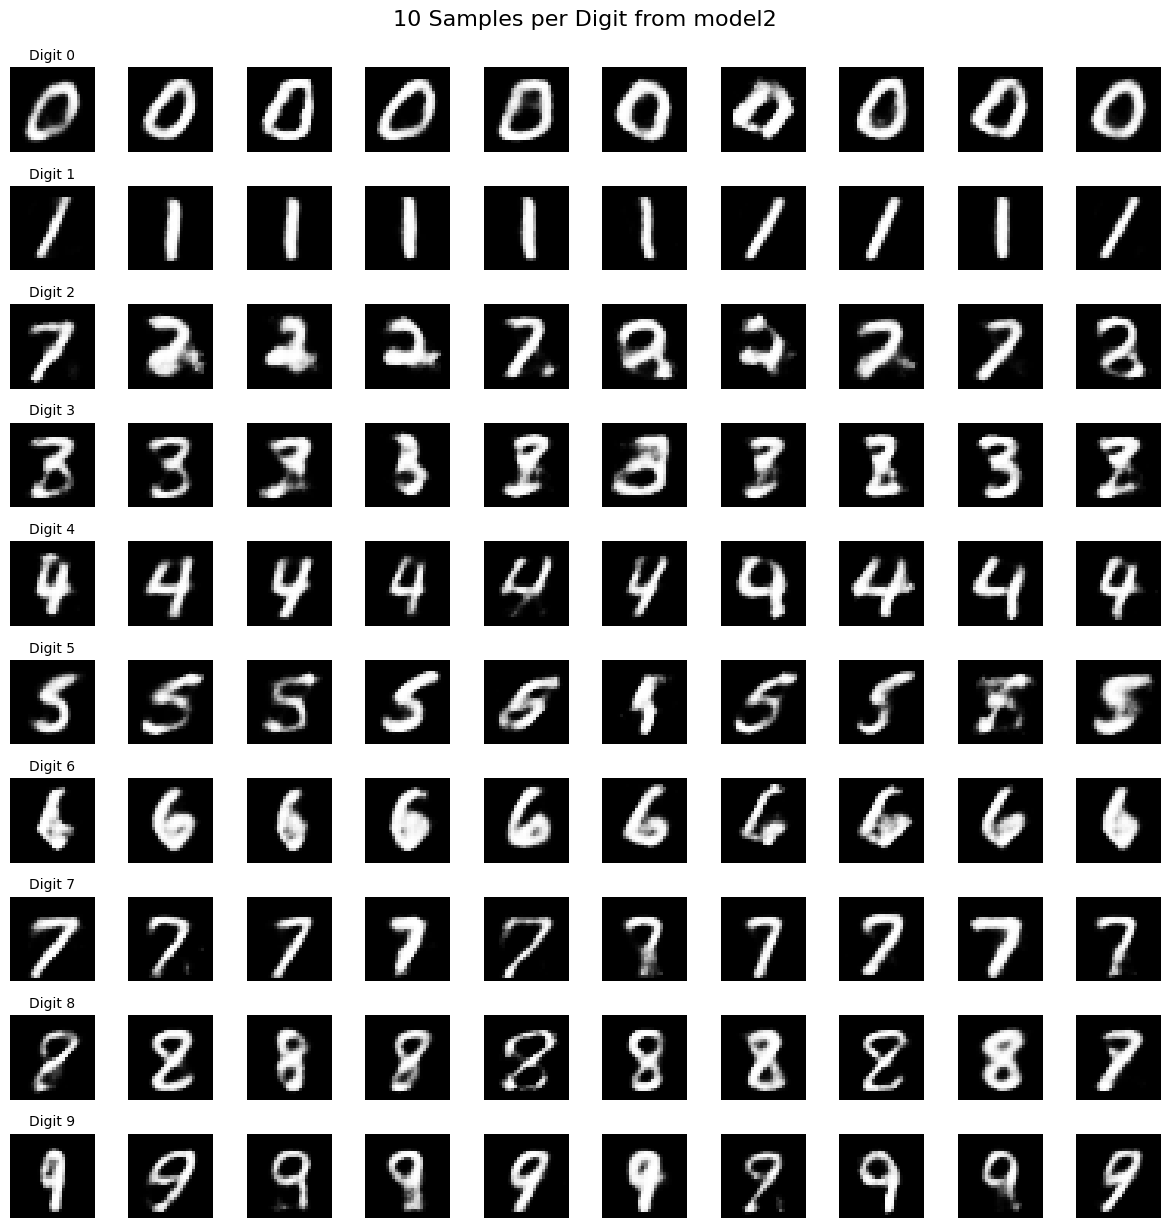

In [7]:
# plot some data 
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28,        28]
labels = y_before_filter  # [N] 
# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()
# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)
plt.tight_layout()
plt.suptitle("10 Samples per Digit from model2", y=1.02, fontsize=16)
plt.show()  